# Final Project Submission

**Gold close Prediction** - Predicting Gold close rate

File link - https://colab.research.google.com/drive/1c41bc0_VpLEBXwJcrGdDEwRaD4RjRGdh?usp=sharing

Dataset Drive link - https://drive.google.com/uc?id=1FNJPEEzHBAfSpVOUKtCyi0wcp5VnnN7o

Kaggle dataset link - https://www.kaggle.com/datasets/franciscogcc/financial-data/data


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Data Preprocessing

Get the Dataset

In [2]:
# Get the dataset
!gdown 1FNJPEEzHBAfSpVOUKtCyi0wcp5VnnN7o --fuzzy

Downloading...
From: https://drive.google.com/uc?id=1FNJPEEzHBAfSpVOUKtCyi0wcp5VnnN7o
To: /content/financial_regression.csv
100% 1.46M/1.46M [00:00<00:00, 24.8MB/s]


Read the dataset

In [3]:
data = pd.read_csv('financial_regression.csv')
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

Number of rows: 3904
Number of columns: 47


In [4]:
data.head()

,date,sp500 open,sp500 high,sp500 low,sp500 close,sp500 volume,sp500 high-low,nasdaq open,nasdaq high,nasdaq low,...,palladium high,palladium low,palladium close,palladium volume,palladium high-low,gold open,gold high,gold low,gold close,gold volume
0,2010-01-14,114.49,115.14,114.42,114.93,115646960.0,0.72,46.26,46.520,46.22,...,45.02,43.86,44.84,364528.0,1.16,111.51,112.37,110.79,112.03,18305238.0
1,2010-01-15,114.73,114.84,113.20,113.64,212252769.0,1.64,46.46,46.550,45.65,...,45.76,44.40,45.76,442210.0,1.36,111.35,112.01,110.38,110.86,18000724.0
2,2010-01-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-19,113.62,115.13,113.59,115.06,138671890.0,1.54,45.96,46.640,45.95,...,47.08,45.70,46.94,629150.0,1.38,110.95,111.75,110.83,111.52,10467927.0
4,2010-01-20,114.28,114.45,112.98,113.89,216330645.0,1.47,46.27,46.604,45.43,...,47.31,45.17,47.05,643198.0,2.14,109.97,110.05,108.46,108.94,17534231.0


Drop duplicate rows

In [5]:
# Drop duplicate rows
data = data.drop_duplicates()

Check Missing values Percentage

In [6]:
missing_percent = data.isnull().mean().sort_values(ascending=False)
print(missing_percent)


GDP                   0.985400
CPI                   0.954918
us_rates_%            0.954918
usd_chf               0.053791
eur_usd               0.053791
sp500 volume          0.047387
sp500 open            0.047387
nasdaq close          0.047387
sp500 high-low        0.047387
nasdaq open           0.047387
nasdaq high           0.047387
nasdaq high-low       0.047387
sp500 close           0.047387
sp500 high            0.047387
sp500 low             0.047387
platinum high         0.047387
nasdaq volume         0.047387
nasdaq low            0.047387
silver open           0.047387
silver high           0.047387
silver low            0.047387
silver close          0.047387
silver volume         0.047387
silver high-low       0.047387
oil open              0.047387
oil high              0.047387
oil low               0.047387
oil close             0.047387
oil volume            0.047387
oil high-low          0.047387
platinum open         0.047387
palladium close       0.047387
platinum

Remove columns with missing values > threshold

In [7]:
threshold = 0.5
cols_to_drop = missing_percent[missing_percent > threshold].index.tolist()
data.drop(columns=cols_to_drop, inplace=True)
print("Dropped columns:", cols_to_drop)


Dropped columns: ['GDP', 'CPI', 'us_rates_%']


Drop NaN

In [8]:
before = len(data)
data.dropna(inplace=True)
print("Rows removed due to missing values:", before - len(data))


Rows removed due to missing values: 227


In [9]:
# Preview the cleaned dataset after initial drops
print("After dropna and column drops:")
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])
print("Columns:", list(data.columns))


After dropna and column drops:
Number of rows: 3677
Number of columns: 44
Columns: ['date', 'sp500 open', 'sp500 high', 'sp500 low', 'sp500 close', 'sp500 volume', 'sp500 high-low', 'nasdaq open', 'nasdaq high', 'nasdaq low', 'nasdaq close', 'nasdaq volume', 'nasdaq high-low', 'usd_chf', 'eur_usd', 'silver open', 'silver high', 'silver low', 'silver close', 'silver volume', 'silver high-low', 'oil open', 'oil high', 'oil low', 'oil close', 'oil volume', 'oil high-low', 'platinum open', 'platinum high', 'platinum low', 'platinum close', 'platinum volume', 'platinum high-low', 'palladium open', 'palladium high', 'palladium low', 'palladium close', 'palladium volume', 'palladium high-low', 'gold open', 'gold high', 'gold low', 'gold close', 'gold volume']


Fill the missing columns with median or mode

In [10]:
for col in data.columns:
    if data[col].dtype == 'object':
        data[col].fillna(data[col].mode()[0], inplace=True)
    else:
        data[col].fillna(data[col].median(), inplace=True)


/tmp/ipython-input-314952444.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)
/tmp/ipython-input-314952444.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [11]:
print("Remaining missing values:", data.isnull().sum().sum())


Remaining missing values: 0


We removed **Gold Volume** to prevent **data leakage** and keep the prediction realistic—daily volume is often only fully known by/after market close, so using it to predict **Gold Close** can make the task artificially easy and not representative of real-world forecasting.


In [12]:
label_col = "gold close"
leakage_cols = ["gold volume"]  # removed to prevent leakage / unrealistic prediction

# Drop leakage columns if present
data = data.drop(columns=leakage_cols, errors="ignore")

# Identify feature columns (everything except label and leakage columns)
feature_cols = [c for c in data.columns if c != label_col]

print("Label column:", label_col)
print("Leakage columns removed (if present):", leakage_cols)
print("Number of feature columns:", len(feature_cols))

Label column: gold close
Leakage columns removed (if present): ['gold volume']
Number of feature columns: 42


Separates the dataset into numeric and categorical columns

In [13]:
numeric_cols = data.select_dtypes(include=['number']).columns.tolist()
categorical_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


Numeric columns: ['sp500 open', 'sp500 high', 'sp500 low', 'sp500 close', 'sp500 volume', 'sp500 high-low', 'nasdaq open', 'nasdaq high', 'nasdaq low', 'nasdaq close', 'nasdaq volume', 'nasdaq high-low', 'usd_chf', 'eur_usd', 'silver open', 'silver high', 'silver low', 'silver close', 'silver volume', 'silver high-low', 'oil open', 'oil high', 'oil low', 'oil close', 'oil volume', 'oil high-low', 'platinum open', 'platinum high', 'platinum low', 'platinum close', 'platinum volume', 'platinum high-low', 'palladium open', 'palladium high', 'palladium low', 'palladium close', 'palladium volume', 'palladium high-low', 'gold open', 'gold high', 'gold low', 'gold close']
Categorical columns: ['date']


Histogram before Cleanup

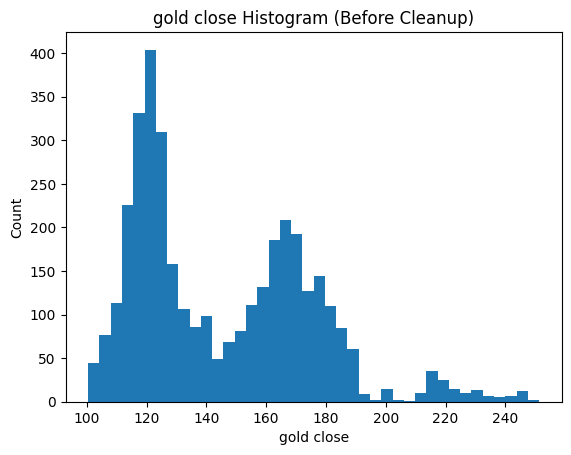

In [14]:
# ---- Clean and analyze the regression label ----
# Histogram BEFORE cleanup
plt.figure()
plt.hist(data[label_col], bins=40)
plt.title(f"{label_col} Histogram (Before Cleanup)")
plt.xlabel(label_col)
plt.ylabel("Count")
plt.show()


Removes extreme outliers from the regression label

In [15]:
# Remove extreme/skewed values if needed (IQR label outliers)
K_LABEL = 1.5
q1, q3 = data[label_col].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - K_LABEL * iqr, q3 + K_LABEL * iqr

before_rows = len(data)
mask = data[label_col].between(low, high)
data = data.loc[mask].copy()
print(f"Label outliers removed: {before_rows - len(data)} rows (K_LABEL={K_LABEL})")


Label outliers removed: 23 rows (K_LABEL=1.5)


Histogram after Cleanup

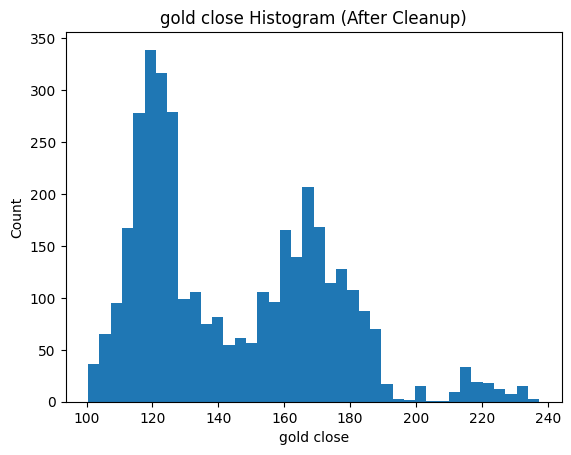

In [16]:
# Histogram AFTER cleanup
plt.figure()
plt.hist(data[label_col], bins=40)
plt.title(f"{label_col} Histogram (After Cleanup)")
plt.xlabel(label_col)
plt.ylabel("Count")
plt.show()


Remove extreme outliers in features

In [17]:
# Remove extreme outliers in FEATURES (DROP ROWS)
K_FEAT = 3.0  # 3.0 = extreme-only; use 1.5 if you want stricter

num_cols = data.select_dtypes(include="number").columns.tolist()
feature_num_cols = [c for c in num_cols if c != label_col]  # don't outlier-filter the label

Q1 = data[feature_num_cols].quantile(0.25)
Q3 = data[feature_num_cols].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - K_FEAT * IQR
upper = Q3 + K_FEAT * IQR

# Keep rows that are within bounds for ALL feature columns
mask = ~((data[feature_num_cols] < lower) | (data[feature_num_cols] > upper)).any(axis=1)

print("Rows before outlier removal:", data.shape[0])
data = data.loc[mask].copy()
print("Rows after outlier removal :", data.shape[0])
print("Rows removed:", int((~mask).sum()))


Rows before outlier removal: 3654
Rows after outlier removal : 3108
Rows removed: 546


classify the continuous label into bins

In [18]:
# Create 4 balanced bins using quantiles
data['gold_bin'] = pd.qcut(data[label_col], q=4, labels=False)

print("Class counts:")
print(data['gold_bin'].value_counts())


Class counts:
gold_bin
0    779
2    778
3    776
1    775
Name: count, dtype: int64


Encode categorical Features

In [19]:
# ---- Encode categorical (text) features (but NEVER encode the label/bin label) ----
label_col = "gold close"
label_bin_col = "gold_bin"

categorical_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_cols = [c for c in categorical_cols if c not in [label_col, label_bin_col]]

data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

Min–Max Scaling: Normalize numeric features to a 0–1 range (excluding target columns)

In [20]:
# ---- Normalize numeric feature columns (exclude targets) ----
numeric_cols_encoded = data_encoded.select_dtypes(include=['number']).columns.tolist()
scale_cols = [c for c in numeric_cols_encoded if c not in [label_col, label_bin_col]]

scaler = MinMaxScaler()
data_encoded[scale_cols] = scaler.fit_transform(data_encoded[scale_cols])

print("Encoded+Scaled shape:", data_encoded.shape)
print("Scaled feature count:", len(scale_cols))


Encoded+Scaled shape: (3108, 3150)
Scaled feature count: 41


Define X and Targets: Split the data into features (X) and two labels, gold close for regression and gold_bin for classification and print their shapes.

In [21]:
label_bin_col = "gold_bin"
X = data_encoded.drop(columns=[label_col, label_bin_col])
y_reg = data_encoded[label_col]       # regression target
y_clf = data_encoded[label_bin_col]      # classification target

print("Features shape:", X.shape)
print("Regression label shape:", y_reg.shape)
print("Classification label shape:", y_clf.shape)


Features shape: (3108, 3148)
Regression label shape: (3108,)
Classification label shape: (3108,)


# Problem Statement

#### Dataset and Description Link

For this project I use the **Gold Price Regression / Financial Data** dataset from Kaggle:  
Drive - https://drive.google.com/uc?id=1FNJPEEzHBAfSpVOUKtCyi0wcp5VnnN7o

Kaggle - https://www.kaggle.com/datasets/franciscogcc/financial-data/data

This dataset is a **time-series of daily financial data** that includes multiple market indices, commodities, economic indicators and foreign exchange (FX) rates. Market indices and commodities are represented via exchange-traded funds (ETFs).

The dataset was originally designed for **gold price prediction**, with a rich set of financial indicators acting as explanatory variables.


#### What I'm Predicting

I focus on predicting the **daily closing price of gold**, using the column:

- **Label (regression target):** `gold close`  
  (final closing value of gold for each trading day)

I use this both as:
1. A **regression target** (predict the numeric closing price), and  
2. A **classification target**, by binning `gold close` into four quantile-based bins that represent different price regimes (e.g., very low, low, high, very high).


#### Label and Feature Columns

- **Label column (Y):**
  - `gold close`: daily closing price of gold.

- **Feature columns (X):**
  After cleaning (dropping columns with too many missing values, handling outliers, encoding categoricals, and scaling numerics), the features include:

  1. **Gold-specific features**
     - `gold open`: opening price of gold  
     - `gold high`: intraday high price  
     - `gold low`: intraday low price  
     - (optional) `gold volume`: trading volume  

  2. **Global equity indices & ETFs** (risk sentiment / market performance)

  3. **Other commodities** (may co-move with gold as alternative assets)

  4. **Foreign exchange (FX) rates** (USD strength impacts gold price)

  5. **Additional financial indicators** (macro/volatility/rates proxies)

In the cleaned modeling table, **all non-label columns** after preprocessing are treated as features. `gold close` is the continuous label, and `label_bin` (the binned version) is used for classification experiments.


#### Why This Prediction Is Logical

Predicting `gold close` from these features is economically and statistically reasonable because gold behaves like a financial asset and safe-haven instrument. Its price is influenced by equity market conditions, other commodity markets, FX rates (especially USD strength), and broader macro-financial indicators.

Therefore, using the dataset's financial features to predict `gold close` and its binned version is logically consistent with financial intuition and the dataset's purpose, and it aligns with the course requirement to perform both regression and classification on a real-world problem.


**Note on prediction scope:** The features include same-day market indicators (and may include gold-related price fields), so this project is framed as same-day estimation of Gold Close rather than a true future forecast. This helps explain the very high R² seen in regression.

# Feature Selection / Extraction

**Create Feature Matrix:** Remove the target columns to build the candidate feature set `X` and extract `y_reg` and `y_clf` for modeling.


In [22]:
# Define candidate features
drop_targets = [label_col, label_bin_col]
drop_targets = [c for c in drop_targets if c in data_encoded.columns]

X = data_encoded.drop(columns=drop_targets).copy()
y_reg = data_encoded[label_col].copy()
y_clf = data_encoded[label_bin_col].copy() if label_bin_col in data_encoded.columns else None

print("Initial feature count:", X.shape[1])


Initial feature count: 3148


Drop constant and near-constant features to remove uninformative columns and reduce noise before modeling.


In [23]:
# Remove constant / near-constant features

# Constant: nunique <= 1
constant_cols = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]
X = X.drop(columns=constant_cols)
print("Removed constant cols:", len(constant_cols))

# Near-constant: one value dominates >= threshold (e.g., 99.5%)
NEAR_CONST_THRESHOLD = 0.995
near_constant_cols = []
for c in X.columns:
    top_freq = X[c].value_counts(normalize=True, dropna=False).iloc[0]
    if top_freq >= NEAR_CONST_THRESHOLD:
        near_constant_cols.append(c)

X = X.drop(columns=near_constant_cols)
print("Removed near-constant cols:", len(near_constant_cols))
print("Features after variance filtering:", X.shape[1])


Removed constant cols: 0
Removed near-constant cols: 3107
Features after variance filtering: 41


Confusion Matrix

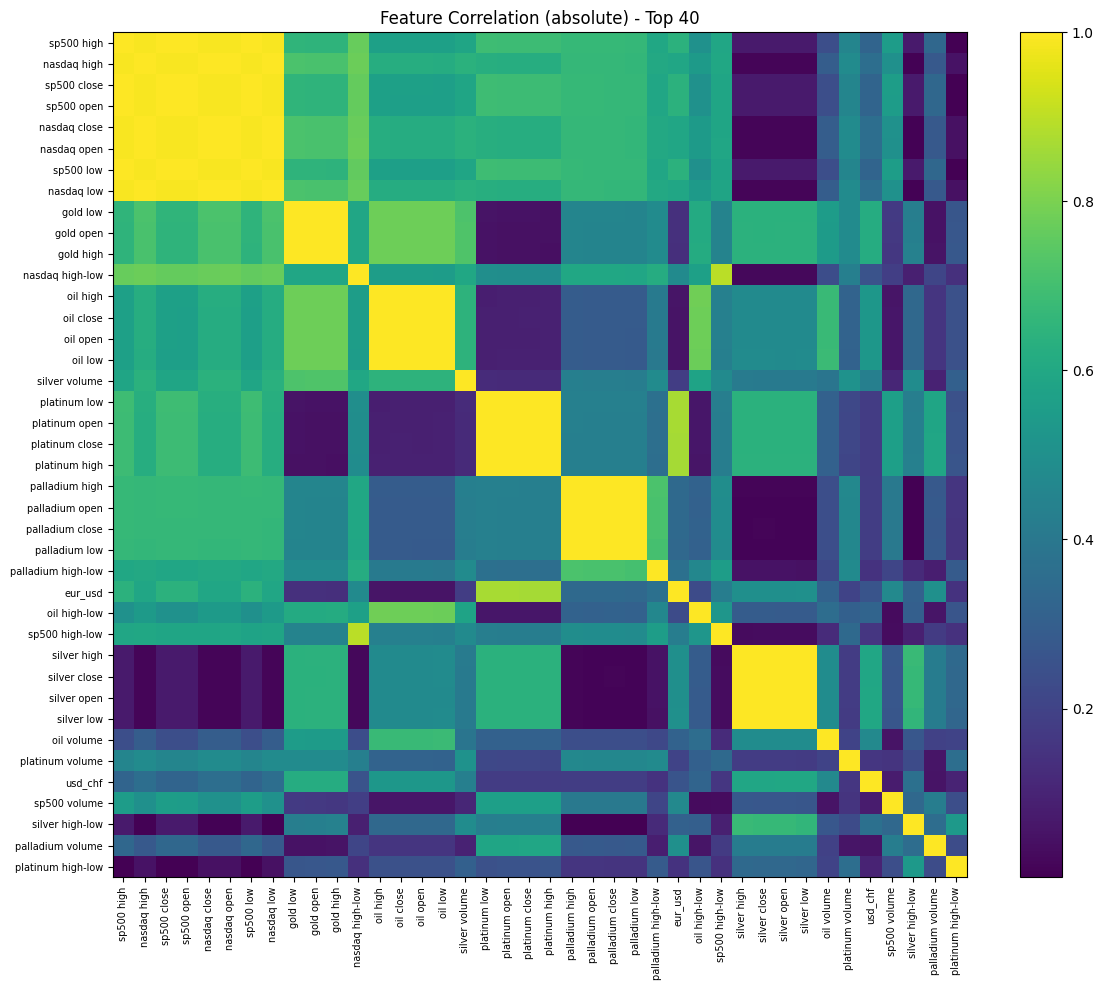

Highly correlated features dropped (>|0.95|): 21
Final selected feature count: 20


In [24]:
# Correlation plot + remove redundant features

# Only for numeric columns (after get_dummies everything should be numeric, but this is safe)
X_num = X.select_dtypes(include=[np.number])

# Correlation matrix
corr = X_num.corr().abs()

top_n = min(40, corr.shape[0])
top_cols = corr.mean().sort_values(ascending=False).head(top_n).index
corr_small = corr.loc[top_cols, top_cols]

plt.figure(figsize=(12, 10))
plt.imshow(corr_small.values, aspect="auto")
plt.title(f"Feature Correlation (absolute) - Top {top_n}")
plt.xticks(np.arange(top_n), corr_small.columns, rotation=90, fontsize=7)
plt.yticks(np.arange(top_n), corr_small.index, fontsize=7)
plt.colorbar()
plt.tight_layout()
plt.show()


# Drop highly correlated features (keep one from each group)
CORR_THRESHOLD = 0.95

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper.columns if any(upper[col] > CORR_THRESHOLD)]

X_selected = X.drop(columns=to_drop_corr).copy()

print(f"Highly correlated features dropped (>|{CORR_THRESHOLD}|):", len(to_drop_corr))
print("Final selected feature count:", X_selected.shape[1])


Final Feature List

In [25]:
# Freeze the feature list for the rest of project
feature_cols = X_selected.columns.tolist()
pd.Series(feature_cols).to_csv("selected_features.csv", index=False, header=False)

df_model = pd.concat([X_selected, y_reg, y_clf], axis=1)

print("df_model shape:", df_model.shape)
display(df_model.head())


df_model shape: (3108, 22)


,sp500 open,sp500 volume,sp500 high-low,nasdaq volume,nasdaq high-low,usd_chf,eur_usd,silver open,silver volume,silver high-low,...,oil high-low,platinum open,platinum volume,platinum high-low,palladium open,palladium volume,palladium high-low,gold open,gold close,gold_bin
12,0.010909,0.540404,0.119249,0.951861,0.018310,0.736802,0.847598,0.087282,0.078721,0.312150,...,0.317393,0.698115,0.324179,0.725285,0.008960,0.696694,0.117197,0.041703,108.35,0
14,0.014654,0.497582,0.062911,0.634602,0.030159,0.737827,0.848191,0.095075,0.042597,0.224188,...,0.215349,0.748214,0.221807,0.523682,0.016789,0.437811,0.108280,0.059638,108.70,0
17,0.007857,0.645961,0.114554,0.640271,0.029365,0.764992,0.807076,0.049875,0.104719,0.192092,...,0.218868,0.660842,0.264411,0.323355,0.000000,0.198655,0.075159,0.025445,104.04,0
18,0.008701,0.974338,0.148357,0.820754,0.046032,0.750897,0.826053,0.054239,0.101172,0.304146,...,0.819874,0.678833,0.321421,0.555581,0.004271,0.906887,0.049682,0.031059,105.41,0
19,0.008528,0.693286,0.111737,0.638426,0.030952,0.761404,0.811623,0.058603,0.068157,0.216104,...,0.384250,0.687183,0.165411,0.510922,0.005694,0.335417,0.100637,0.030694,105.12,0


Split the dataset

In [26]:
# Use the frozen feature list from Section 3
X_final = X_selected.copy()
y_reg_final = data_encoded.loc[X_final.index, label_col].copy()
y_clf_final = data_encoded.loc[X_final.index, "gold_bin"].copy()

# One split used for ALL models in Section 4 and Section 5
train_idx, test_idx = train_test_split(
    X_final.index,
    test_size=0.2,
    random_state=42,
    stratify=y_clf_final
)

X_train = X_final.loc[train_idx]
X_test  = X_final.loc[test_idx]

y_train_reg = y_reg_final.loc[train_idx]
y_test_reg  = y_reg_final.loc[test_idx]

y_train_clf = y_clf_final.loc[train_idx]
y_test_clf  = y_clf_final.loc[test_idx]

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train class counts:\n", y_train_clf.value_counts())
print("Test class counts:\n", y_test_clf.value_counts())


Train shape: (2486, 20) Test shape: (622, 20)
Train class counts:
 gold_bin
0    623
2    622
3    621
1    620
Name: count, dtype: int64
Test class counts:
 gold_bin
2    156
0    156
1    155
3    155
Name: count, dtype: int64


# Comparing Supervised Models

Regression Models - We chose **Linear Regression** because it’s the **required baseline**, **Ridge** as a simple, stronger **regularized linear** model for correlated/noisy features, and **Random Forest Regressor** as a robust **non-linear** model to capture feature interactions.


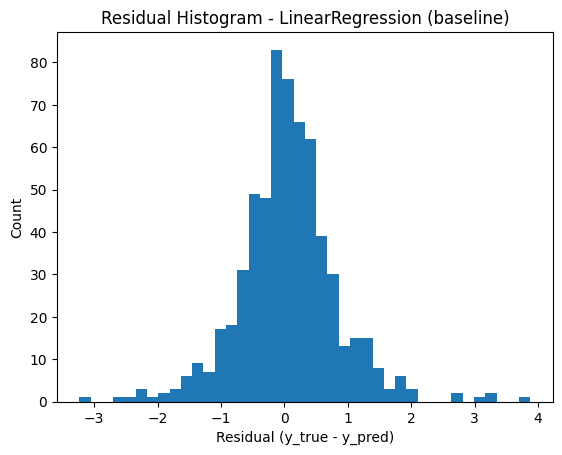

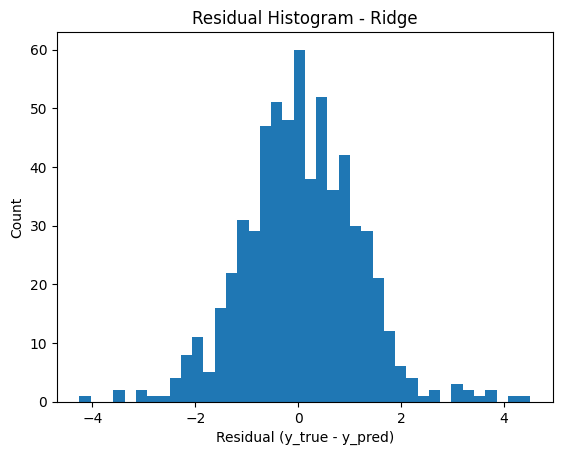

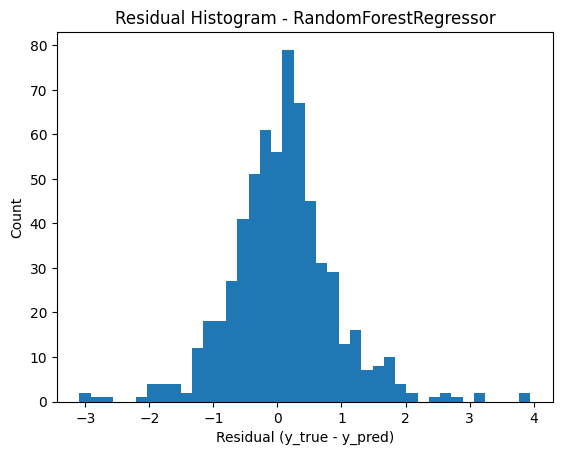

Regression Results:
LinearRegression (baseline) {'MSE': 0.6078, 'MAE': 0.5579, 'RMSE': np.float64(0.7796), 'R2': 0.9993}
Ridge {'MSE': 1.2554, 'MAE': 0.8617, 'RMSE': np.float64(1.1205), 'R2': 0.9985}
RandomForestRegressor {'MSE': 0.6893, 'MAE': 0.6027, 'RMSE': np.float64(0.8303), 'R2': 0.9992}
Best regression model: LinearRegression (baseline)


In [27]:
reg_models = {
    "LinearRegression (baseline)": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "RandomForestRegressor": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
}

reg_results = {}

for name, model in reg_models.items():
    model.fit(X_train, y_train_reg)
    pred = model.predict(X_test)

    mse = mean_squared_error(y_test_reg, pred)
    mae = mean_absolute_error(y_test_reg, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_reg, pred)

    reg_results[name] = {"MSE": mse, "MAE": mae, "RMSE": rmse, "R2": r2, "model": model}

    # Residual histogram (required qualitative)
    residuals = y_test_reg - pred
    plt.figure()
    plt.hist(residuals, bins=40)
    plt.title(f"Residual Histogram - {name}")
    plt.xlabel("Residual (y_true - y_pred)")
    plt.ylabel("Count")
    plt.show()

# Print summary
print("Regression Results:")
for k, v in reg_results.items():
    print(k, {m: round(v[m], 4) for m in ["MSE", "MAE", "RMSE", "R2"]})

# Pick best regression model (lowest MAE)
best_reg_name = min(reg_results, key=lambda k: reg_results[k]["MAE"])
best_reg_model = reg_results[best_reg_name]["model"]
print("Best regression model:", best_reg_name)


Classification Models - We used **Logistic Regression** because it’s the required baseline, **MLP** because the rubric requires a neural network with at least one hidden layer to capture non-linear patterns, and **Random Forest** as a strong non-linear benchmark.


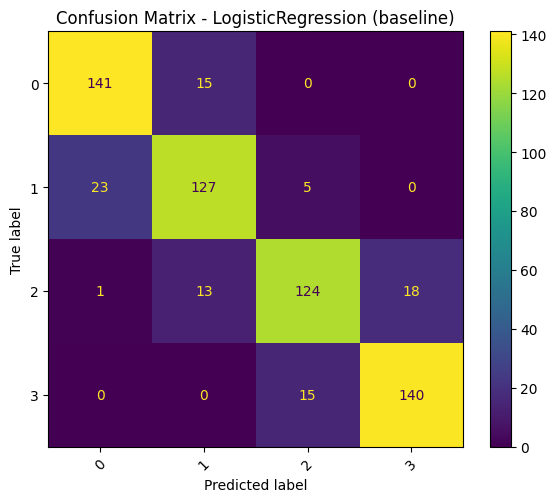

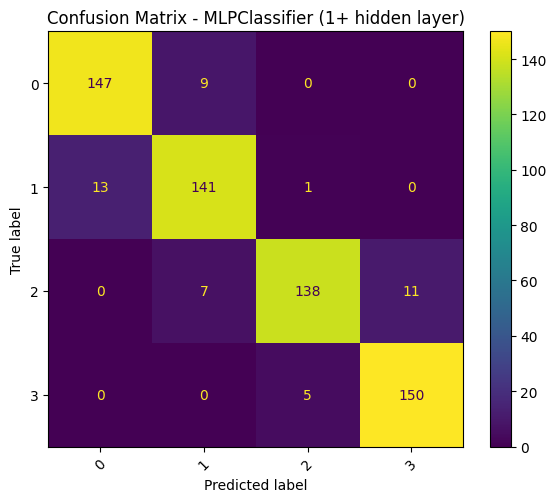

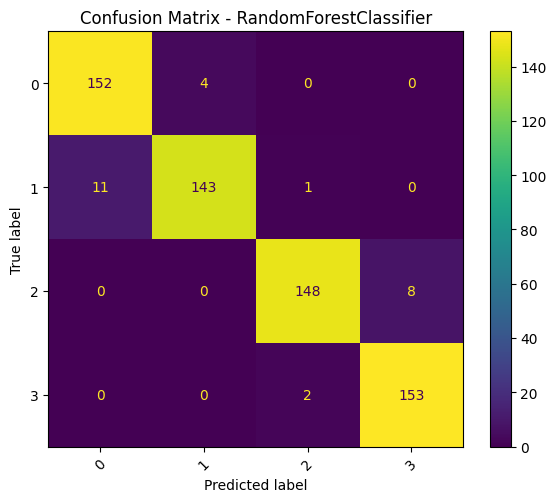

Classification Results:
LogisticRegression (baseline) {'Accuracy': 0.8553, 'F1': 0.8548, 'Precision': 0.8553, 'Recall': 0.8553}
MLPClassifier (1+ hidden layer) {'Accuracy': 0.926, 'F1': 0.9259, 'Precision': 0.9267, 'Recall': 0.9261}
RandomForestClassifier {'Accuracy': 0.9582, 'F1': 0.9581, 'Precision': 0.9589, 'Recall': 0.9582}
Best classification model: RandomForestClassifier


In [28]:
clf_models = {
    "LogisticRegression (baseline)": LogisticRegression(max_iter=3000, random_state=42),
    "MLPClassifier (1+ hidden layer)": MLPClassifier(hidden_layer_sizes=(64,32), max_iter=400,
                                                     random_state=42, early_stopping=True),
    "RandomForestClassifier": RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)
}

clf_results = {}

for name, model in clf_models.items():
    model.fit(X_train, y_train_clf)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test_clf, pred)
    prec = precision_score(y_test_clf, pred, average="macro", zero_division=0)
    rec = recall_score(y_test_clf, pred, average="macro", zero_division=0)
    f1 = f1_score(y_test_clf, pred, average="macro", zero_division=0)

    clf_results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "model": model}

    # Confusion matrix (required qualitative)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(y_test_clf, pred, xticks_rotation=45, ax=ax)
    ax.set_title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()

print("Classification Results:")
for k,v in clf_results.items():
    print(k, {m: round(v[m], 4) for m in ["Accuracy","F1","Precision","Recall"]})

# Pick best classification model (highest F1-macro)
best_clf_name = max(clf_results, key=lambda k: clf_results[k]["F1"])
best_clf_model = clf_results[best_clf_name]["model"]
print("Best classification model:", best_clf_name)


# Unsupervised + Supervised Pipeline

**Choose K for KMeans:** We test K=2–10 using the silhouette score, pick the best K, fit KMeans on the training set, and assign cluster IDs to both train and test samples.


In [29]:
sil_scores = {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X_train)
    sil_scores[k] = silhouette_score(X_train, km.labels_)

best_k = max(sil_scores, key=sil_scores.get)
print("Silhouette scores:", sil_scores)
print("Chosen K:", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
kmeans.fit(X_train)

train_clusters = kmeans.labels_
test_clusters = kmeans.predict(X_test)


Silhouette scores: {2: np.float64(0.3707961573728343), 3: np.float64(0.3843413798226096), 4: np.float64(0.3248293917205813), 5: np.float64(0.2925824041953808), 6: np.float64(0.21954196008412294), 7: np.float64(0.21654425332051916), 8: np.float64(0.21276578007188543), 9: np.float64(0.204971134389117), 10: np.float64(0.2074915247385704)}
Chosen K: 3


**Train cluster-specific models:** For each cluster, we fit the best regression and classification models on that cluster’s training data, and fall back to the global best models if a cluster has too few samples.


In [30]:
MIN_CLUSTER_SAMPLES = 30  # fallback threshold

# Re-train global best models on full training data (fallback models)
global_reg = deepcopy(best_reg_model).fit(X_train, y_train_reg)
global_clf = deepcopy(best_clf_model).fit(X_train, y_train_clf)

cluster_reg_models = {}
cluster_clf_models = {}

for c in range(best_k):
    idx_c = X_train.index[train_clusters == c]
    if len(idx_c) < MIN_CLUSTER_SAMPLES:
        cluster_reg_models[c] = global_reg
        cluster_clf_models[c] = global_clf
        continue

    Xc = X_train.loc[idx_c]
    yrc = y_train_reg.loc[idx_c]
    ycc = y_train_clf.loc[idx_c]

    cluster_reg_models[c] = deepcopy(best_reg_model).fit(Xc, yrc)
    cluster_clf_models[c] = deepcopy(best_clf_model).fit(Xc, ycc)

print("Cluster models trained. Fallback used for small clusters where needed.")


Cluster models trained. Fallback used for small clusters where needed.


Supervised + Unsupervised Learning


HYBRID REGRESSION METRICS:
MSE : 0.6316
MAE : 0.5726
RMSE: 0.7948


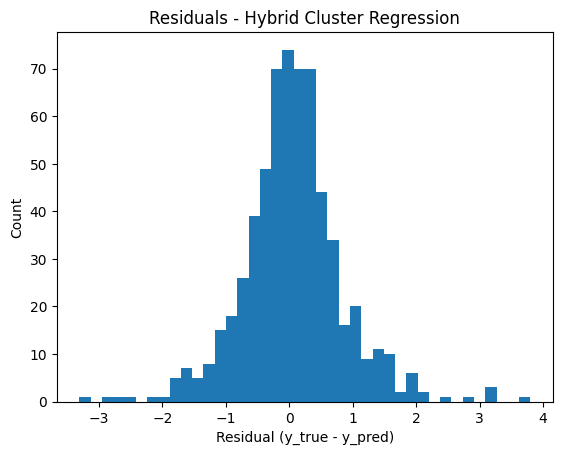


HYBRID CLASSIFICATION METRICS:
Accuracy : 0.955
Precision: 0.9558
Recall   : 0.955
F1 (macro): 0.9549


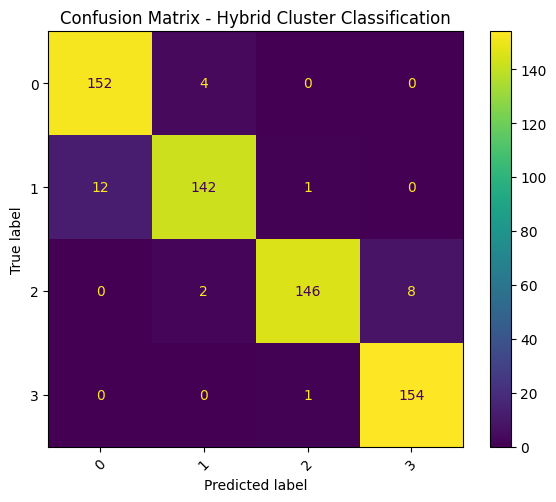

In [31]:
# --- Hybrid predictions (cluster → specialized model) ---
hybrid_reg_preds = []
hybrid_clf_preds = []

for i, idx in enumerate(X_test.index):
    c = int(test_clusters[i])
    x1 = X_test.loc[[idx]]

    reg_m = cluster_reg_models.get(c, global_reg)
    clf_m = cluster_clf_models.get(c, global_clf)

    hybrid_reg_preds.append(reg_m.predict(x1)[0])
    hybrid_clf_preds.append(clf_m.predict(x1)[0])

hybrid_reg_preds = np.array(hybrid_reg_preds)
hybrid_clf_preds = np.array(hybrid_clf_preds)

# --- Regression metrics + residual histogram (required qualitative for regression) ---
hyb_mse  = mean_squared_error(y_test_reg, hybrid_reg_preds)
hyb_mae  = mean_absolute_error(y_test_reg, hybrid_reg_preds)
hyb_rmse = np.sqrt(hyb_mse)

print("\nHYBRID REGRESSION METRICS:")
print("MSE :", round(hyb_mse, 4))
print("MAE :", round(hyb_mae, 4))
print("RMSE:", round(hyb_rmse, 4))


plt.figure()
plt.hist(y_test_reg - hybrid_reg_preds, bins=40)
plt.title("Residuals - Hybrid Cluster Regression")
plt.xlabel("Residual (y_true - y_pred)")
plt.ylabel("Count")
plt.show()

# --- Classification metrics + confusion matrix (required qualitative for classification) ---
hyb_acc  = accuracy_score(y_test_clf, hybrid_clf_preds)
hyb_prec = precision_score(y_test_clf, hybrid_clf_preds, average="macro", zero_division=0)
hyb_rec  = recall_score(y_test_clf, hybrid_clf_preds, average="macro", zero_division=0)
hyb_f1   = f1_score(y_test_clf, hybrid_clf_preds, average="macro", zero_division=0)

print("\nHYBRID CLASSIFICATION METRICS:")
print("Accuracy :", round(hyb_acc, 4))
print("Precision:", round(hyb_prec, 4))
print("Recall   :", round(hyb_rec, 4))
print("F1 (macro):", round(hyb_f1, 4))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_clf, hybrid_clf_preds, xticks_rotation=45, ax=ax)
ax.set_title("Confusion Matrix - Hybrid Cluster Classification")
plt.tight_layout()
plt.show()


Comparision


REGRESSION COMPARISON
Global best: LinearRegression (baseline)  MSE: 0.6078  MAE: 0.5579  RMSE: 0.7796
Hybrid (cluster):  MSE: 0.6316  MAE: 0.5726  RMSE: 0.7948


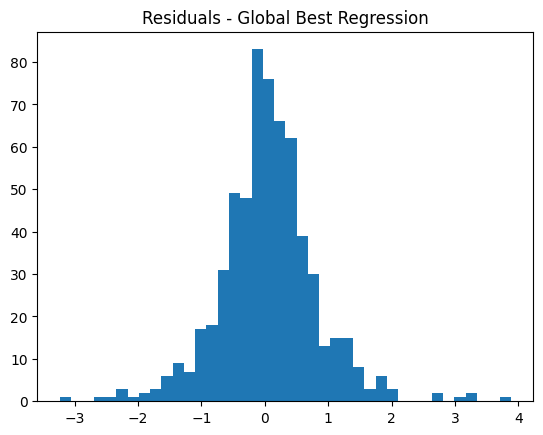

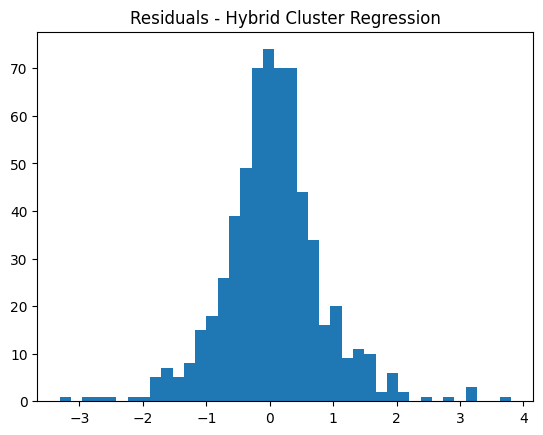


CLASSIFICATION COMPARISON
Global best: RandomForestClassifier  F1: 0.9581  Acc: 0.9582
Hybrid (cluster):  F1: 0.9549  Acc: 0.955


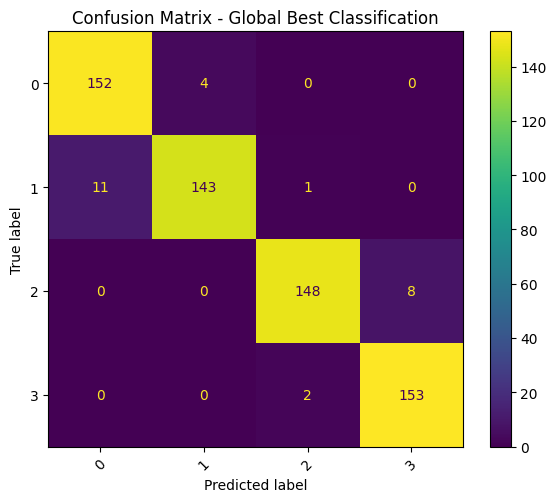

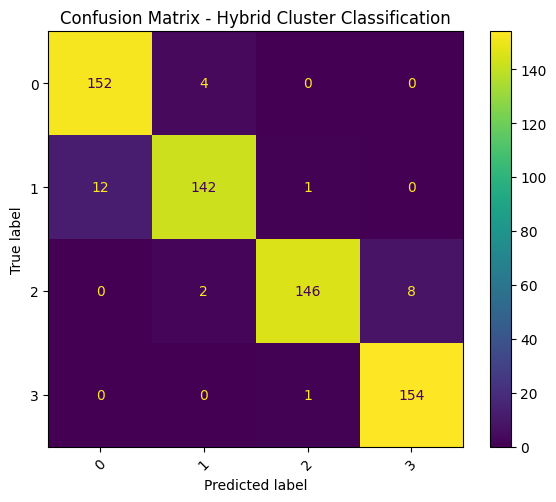

In [32]:
# --- Regression comparison ---
base_reg_pred = global_reg.predict(X_test)

print("\nREGRESSION COMPARISON")

base_mse  = mean_squared_error(y_test_reg, base_reg_pred)
base_mae  = mean_absolute_error(y_test_reg, base_reg_pred)
base_rmse = np.sqrt(base_mse)

hyb_mse2  = mean_squared_error(y_test_reg, hybrid_reg_preds)
hyb_mae2  = mean_absolute_error(y_test_reg, hybrid_reg_preds)
hyb_rmse2 = np.sqrt(hyb_mse2)

print("Global best:", best_reg_name,
      " MSE:", round(base_mse, 4),
      " MAE:", round(base_mae, 4),
      " RMSE:", round(base_rmse, 4))

print("Hybrid (cluster):",
      " MSE:", round(hyb_mse2, 4),
      " MAE:", round(hyb_mae2, 4),
      " RMSE:", round(hyb_rmse2, 4))

plt.figure()
plt.hist(y_test_reg - base_reg_pred, bins=40)
plt.title("Residuals - Global Best Regression")
plt.show()

plt.figure()
plt.hist(y_test_reg - hybrid_reg_preds, bins=40)
plt.title("Residuals - Hybrid Cluster Regression")
plt.show()

# --- Classification comparison ---
base_clf_pred = global_clf.predict(X_test)

print("\nCLASSIFICATION COMPARISON")
print("Global best:", best_clf_name,
      " F1:", round(f1_score(y_test_clf, base_clf_pred, average="macro", zero_division=0), 4),
      " Acc:", round(accuracy_score(y_test_clf, base_clf_pred), 4))

print("Hybrid (cluster):",
      " F1:", round(f1_score(y_test_clf, hybrid_clf_preds, average="macro", zero_division=0), 4),
      " Acc:", round(accuracy_score(y_test_clf, hybrid_clf_preds), 4))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_clf, base_clf_pred, xticks_rotation=45, ax=ax)
ax.set_title("Confusion Matrix - Global Best Classification")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_clf, hybrid_clf_preds, xticks_rotation=45, ax=ax)
ax.set_title("Confusion Matrix - Hybrid Cluster Classification")
plt.tight_layout()
plt.show()



In [33]:
# Use the feature names from your final selected feature matrix
feature_names = X_selected.columns  # or X_train.columns if you're using that

# ---- 1) Regression: LinearRegression coefficients (importance = |coef|) ----
if best_reg_name.startswith("LinearRegression") and hasattr(best_reg_model, "coef_"):
    reg_imp = pd.Series(np.abs(best_reg_model.coef_), index=feature_names).sort_values(ascending=False)
    print("Top 5 features (Regression - LinearRegression, by |coefficient|):")
    display(reg_imp.head(5).to_frame("importance(|coef|)"))
else:
    print("Best regression model is not LinearRegression or has no coef_. Skipping regression coefficient importance.")

# ---- 2) Classification: RandomForest feature_importances_ ----
if best_clf_name.startswith("RandomForest") and hasattr(best_clf_model, "feature_importances_"):
    clf_imp = pd.Series(best_clf_model.feature_importances_, index=feature_names).sort_values(ascending=False)
    print("Top 5 features (Classification - RandomForest, by feature_importance):")
    display(clf_imp.head(5).to_frame("importance"))
else:
    print("Best classification model is not RandomForest or has no feature_importances_. Skipping RF importance.")


Top 5 features (Regression - LinearRegression, by |coefficient|):


,importance(|coef|)
gold open,136.980446
sp500 open,0.383284
platinum high-low,0.342237
eur_usd,0.272751
sp500 volume,0.219063


Top 5 features (Classification - RandomForest, by feature_importance):


,importance
gold open,0.407503
silver open,0.121667
sp500 open,0.098484
palladium open,0.055141
usd_chf,0.046162


# Conclusion & Justification

## Which models performed best and why?
**Best Regression Model:** **LinearRegression (baseline)**  
From the model comparison, the best (non-clustered) regression model was **LinearRegression**, with:
- **MSE:** 0.6078
- **MAE:** 0.5579  
- **RMSE:** 0.7796

This indicates the linear baseline generalized best on the held-out test set. After preprocessing and feature selection, the relationship between the remaining features and **gold close** appears largely linear, and more complex models did not improve generalization. The extremely high R² is likely because the feature set supports same-day estimation rather than true forecasting.

**Best Classification Model:** **RandomForestClassifier**  
The best classification model was **RandomForestClassifier**, with:  
- **F1 (macro):** 0.9581  
- **Accuracy:** 0.9582  

This shows strong and balanced performance across the **gold_bin** classes, which is expected because Random Forests capture nonlinear relationships and feature interactions well for tabular data.


## Which Features Mattered
Feature importance was determined using **absolute LinearRegression coefficients** (regression) and **RandomForest feature_importances** (classification). The most important features were:  
- **Common to both models:** **gold open** (dominant in both), **sp500 open**  
- **Regression (next most important):** **platinum high-low**, **eur_usd**, **sp500 volume**  
- **Classification (next most important):** **silver open**, **palladium open**, **usd_chf**


## Did Clustering Help?
### Regression: **Clustering did NOT help**
Hybrid regression was slightly worse than the global model:  
- **Global:** MSE: 0.6078, MAE 0.5579, RMSE 0.7796  
- **Hybrid:** MSE 0.6316, MAE 0.5726, RMSE 0.7948  

This suggests clustering reduced the effective sample size per cluster, making cluster-specific regression models less stable than a single global model.

### Classification: **Clustering did NOT help**
Hybrid classification was also slightly worse:  
- **Global:** F1 0.9581, Acc 0.9582  
- **Hybrid:** F1 0.9549, Acc 0.9550  

The drop is small, but the global RandomForest already captured the decision boundaries well, so clustering did not add meaningful structure.

**Overall conclusion:** Clustering did not improve performance for this dataset; the global best models remained slightly better.


## What did you learn from your dataset?
- Cleaning the regression label and removing extreme points improved stability and reduced the influence of rare extremes.  
- A simple global linear model can outperform more complex regression models when the cleaned data exhibits mostly linear structure.  
- Quantile binning created balanced classes, supporting stable performance for Logistic Regression/MLP and enabling very strong results for tree-based classification models.  
- The hybrid cluster-based pipeline is useful in real-world settings, but here it likely introduced extra variance due to smaller per-cluster training sets.


## What I Would Do Next (With More Time/Data)
- Tune hyperparameters for RandomForest and MLP (and try Gradient Boosting / XGBoost if allowed).  
- Try alternative clustering methods (e.g., **GMM** or **SOM**) and evaluate whether they produce more meaningful regimes than KMeans.  
- Use a **time-based split** (train earlier dates, test later dates) to better match real-world prediction.
